# Attention-Assisted Hybrid Feature Learning for Leaf Disease Pattern Recognition

**Course:** Pattern Recognition  
**Dataset:** PlantVillage (Kaggle – emmarex/plantdisease)  
**Author:** Rashin Gholijani Farahani  
**Date:** 2025  



## Overview

This notebook presents a **classical yet interpretable pattern recognition pipeline** for plant leaf disease classification.  
Instead of relying on heavy deep learning architectures, the approach focuses on:

- Handcrafted **color, texture, and shape descriptors**
- Feature fusion and ablation analysis
- A lightweight **Mixture-of-Experts attention mechanism** for explainability (XAI)

The goal is to achieve **high accuracy while maintaining interpretability**, making the system suitable for educational, scientific, and practical agricultural applications.



## Key Contributions

- Hybrid feature space (Color + Texture + Shape)
- Strong SVM baseline with balanced learning
- Systematic ablation study
- Feature-group–level attention for explainability
- Fully reproducible experimental pipeline


## Project Structure (Notebook-Oriented)

This notebook follows a clear and reproducible structure:

1. **Dataset Preparation**
   - Downloading PlantVillage via KaggleHub
   - Cleaning labels and removing spurious classes
   - Stratified train / validation / test split

2. **Feature Engineering**
   - Color descriptors (Color Moments, HSV histograms)
   - Texture descriptors (GLCM, LBP)
   - Shape descriptors (contour-based geometric features)

3. **Baseline Classification**
   - Support Vector Machine (RBF kernel)
   - Balanced class weighting
   - PCA analysis (with and without dimensionality reduction)

4. **Ablation Study**
   - Individual and combined feature groups
   - Quantitative comparison using Macro-F1 and Accuracy

5. **Explainable Attention Model**
   - Mixture-of-Experts framework
   - Learned attention weights over feature groups
   - Visualization of feature importance and class-wise contribution

6. **Results & Visualization**
   - Quantitative performance tables
   - Attention weight bar plot
   - Class-wise contribution heatmap


Requirements

The notebook requires the following Python packages:

- numpy
- pandas
- opencv-python
- scipy
- scikit-image
- scikit-learn
- matplotlib
- kagglehub



#  Imports


In [2]:

import json
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [8]:
dataset_path = kagglehub.dataset_download("emmarex/plantdisease")
DATA_DIR = Path(dataset_path)

print("Path to dataset files:", DATA_DIR)

subdirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
if len(subdirs) == 1:
    DATA_DIR = subdirs[0]

root = DATA_DIR
print("Using dataset root:", root)



Path to dataset files: /Users/rashinfarahani/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1
Using dataset root: /Users/rashinfarahani/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage


In [9]:
image_exts = {".jpg", ".jpeg", ".png"}
rows = []

for class_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in image_exts:
            rows.append({
                "path": str(img_path),
                "label": label
            })

df = pd.DataFrame(rows)

print("Before filtering -> Classes:", df["label"].nunique(), "Images:", len(df))

df = df[df["label"] != "PlantVillage"].reset_index(drop=True)

print("After filtering  -> Classes:", df["label"].nunique(), "Images:", len(df))

labels_sorted = sorted(df["label"].unique())
label2id = {lab: i for i, lab in enumerate(labels_sorted)}
df["label_id"] = df["label"].map(label2id)

df.head()


Before filtering -> Classes: 16 Images: 41276
After filtering  -> Classes: 15 Images: 20638


,path,label,label_id
0,/Users/rashinfarahani/.cache/kagglehub/dataset...,Pepper__bell___Bacterial_spot,0
1,/Users/rashinfarahani/.cache/kagglehub/dataset...,Pepper__bell___Bacterial_spot,0
2,/Users/rashinfarahani/.cache/kagglehub/dataset...,Pepper__bell___Bacterial_spot,0
3,/Users/rashinfarahani/.cache/kagglehub/dataset...,Pepper__bell___Bacterial_spot,0
4,/Users/rashinfarahani/.cache/kagglehub/dataset...,Pepper__bell___Bacterial_spot,0


In [10]:
OUT_DIR = Path("outputs_v2")
OUT_DIR.mkdir(exist_ok=True)

SEED = 42

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_id"]
)

df.to_csv(OUT_DIR / "dataset.csv", index=False)
train_df.to_csv(OUT_DIR / "train.csv", index=False)
val_df.to_csv(OUT_DIR / "val.csv", index=False)
test_df.to_csv(OUT_DIR / "test.csv", index=False)

splits = {
    "seed": SEED,
    "num_images": len(df),
    "num_classes": df["label"].nunique(),
    "sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df)
    },
    "labels_sorted": labels_sorted
}

with open(OUT_DIR / "splits.json", "w") as f:
    json.dump(splits, f, indent=2)

print("Dataset split saved to:", OUT_DIR.resolve())
print("Split sizes:", splits["sizes"])


Dataset split saved to: /Users/rashinfarahani/Desktop/master-azad/algoritm/outputs_v2
Split sizes: {'train': 14446, 'val': 3096, 'test': 3096}


In [15]:
IMG_SIZE = (256, 256)
HSV_BINS = 16
EPS = 1e-8

def color_moments(img_rgb):
    feats = []
    for c in range(3):
        ch = img_rgb[..., c].reshape(-1)
        feats.extend([np.mean(ch), np.std(ch), st.skew(ch)])
    return np.array(feats, dtype=np.float32)

def hsv_hist(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    feats = []
    ranges = [(0,180), (0,256), (0,256)]
    for i, (lo, hi) in enumerate(ranges):
        hist = cv2.calcHist([hsv],[i],None,[HSV_BINS],[lo,hi]).flatten()
        hist = hist / (hist.sum() + EPS)
        feats.append(hist)
    return np.concatenate(feats)

def extract_color_features(df):
    X = []
    for p in df["path"]:
        img = cv2.imread(p)
        img = cv2.resize(img, IMG_SIZE)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
        X.append(np.concatenate([color_moments(rgb), hsv_hist(img)]))

    X = np.vstack(X)

    cm_names = [f"cm_{c}_{s}" for c in "RGB" for s in ["mean","std","skew"]]
    hsv_names = [f"hsv_{c}_bin{i}" for c in "HSV" for i in range(HSV_BINS)]
    cols = cm_names + hsv_names

    out = df[["path","label","label_id"]].copy()
    out[cols] = X
    return out


In [16]:
train_feat = extract_color_features(pd.read_csv(OUT_DIR/"train.csv"))
val_feat   = extract_color_features(pd.read_csv(OUT_DIR/"val.csv"))
test_feat  = extract_color_features(pd.read_csv(OUT_DIR/"test.csv"))

train_feat.to_csv(OUT_DIR/"color_features_train.csv", index=False)
val_feat.to_csv(OUT_DIR/"color_features_val.csv", index=False)
test_feat.to_csv(OUT_DIR/"color_features_test.csv", index=False)

print("Color features saved.")


Color features saved.


In [17]:
DISTANCES = [1,2]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ["contrast","homogeneity","energy","correlation"]

LBP_RADIUS = 1
LBP_POINTS = 8
LBP_BINS = LBP_POINTS + 2

def glcm_features(gray):
    levels = 16
    gray_q = (gray / (256/levels)).astype(np.uint8)
    glcm = graycomatrix(gray_q, DISTANCES, ANGLES, levels, symmetric=True, normed=True)
    feats = []
    for p in GLCM_PROPS:
        vals = graycoprops(glcm, p)
        feats.extend([vals.mean(), vals.std()])
    return np.array(feats)

def lbp_features(gray):
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method="uniform")
    hist,_ = np.histogram(lbp.ravel(), bins=LBP_BINS)
    return hist / (hist.sum() + EPS)

def extract_texture_features(df):
    X = []
    for p in df["path"]:
        img = cv2.imread(p)
        img = cv2.resize(img, IMG_SIZE)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        X.append(np.concatenate([glcm_features(gray), lbp_features(gray)]))

    X = np.vstack(X)

    glcm_names = [f"glcm_{p}_{s}" for p in GLCM_PROPS for s in ["mean","std"]]
    lbp_names = [f"lbp_bin{i}" for i in range(LBP_BINS)]

    out = df[["path","label","label_id"]].copy()
    out[glcm_names + lbp_names] = X
    return out


In [18]:
OUT_DIR = Path("outputs_v2")
IMG_SIZE = (256, 256)
EPS = 1e-8

def segment_leaf_mask(img_bgr):
    img = cv2.resize(img_bgr, IMG_SIZE, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower = np.array([25, 25, 25])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask

def shape_features_from_mask(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(cnts) == 0:
        return np.zeros(8, dtype=np.float32)

    c = max(cnts, key=cv2.contourArea)

    area = float(cv2.contourArea(c))
    perimeter = float(cv2.arcLength(c, True))

    x, y, w, h = cv2.boundingRect(c)
    rect_area = float(w * h)

    hull = cv2.convexHull(c)
    hull_area = float(cv2.contourArea(hull))

    circularity = (4.0 * np.pi * area) / (perimeter * perimeter + EPS)
    aspect_ratio = float(w) / (float(h) + EPS)
    extent = area / (rect_area + EPS)
    solidity = area / (hull_area + EPS)
    equiv_diameter = np.sqrt(4.0 * area / (np.pi + EPS))
    irregularity = perimeter / (2.0 * np.sqrt(np.pi * area) + EPS)

    return np.array([
        area,
        perimeter,
        circularity,
        aspect_ratio,
        extent,
        solidity,
        equiv_diameter,
        irregularity
    ], dtype=np.float32)

def extract_shape_features(df):
    X = []
    for p in df["path"].tolist():
        img = cv2.imread(p)
        if img is None:
            raise RuntimeError(f"Could not read image: {p}")
        mask = segment_leaf_mask(img)
        X.append(shape_features_from_mask(mask))

    X = np.vstack(X)

    feat_names = [
        "shape_area",
        "shape_perimeter",
        "shape_circularity",
        "shape_aspect_ratio",
        "shape_extent",
        "shape_solidity",
        "shape_equiv_diameter",
        "shape_irregularity",
    ]

    out = df[["path", "label", "label_id"]].copy()
    out[feat_names] = X
    return out


In [19]:
OUT_DIR = Path("outputs_v2")

def load_and_merge(split_name: str):
    c = pd.read_csv(OUT_DIR / f"color_features_{split_name}.csv")
    t = pd.read_csv(OUT_DIR / f"texture_features_{split_name}.csv")
    s = pd.read_csv(OUT_DIR / f"shape_features_{split_name}.csv")

    dfm = c.merge(t, on=["path", "label", "label_id"], how="inner")
    dfm = dfm.merge(s, on=["path", "label", "label_id"], how="inner")
    return dfm

train = load_and_merge("train")
val   = load_and_merge("val")
test  = load_and_merge("test")


In [20]:
color_cols   = [c for c in train.columns if c.startswith("cm_") or c.startswith("hsv_")]
texture_cols = [c for c in train.columns if c.startswith("glcm_") or c.startswith("lbp_")]
shape_cols   = [c for c in train.columns if c.startswith("shape_")]
all_cols = color_cols + texture_cols + shape_cols

Xtr, ytr = train[all_cols].values, train["label_id"].values
Xv,  yv  = val[all_cols].values,   val["label_id"].values
Xt,  yt  = test[all_cols].values,  test["label_id"].values

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=60, random_state=42)),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                class_weight="balanced",
                random_state=42))
])

print("Training baseline model...")
pipe.fit(Xtr, ytr)

pred_val = pipe.predict(Xv)
print("\nVALIDATION")
print("Val Acc:", accuracy_score(yv, pred_val))
print("Val Macro-F1:", f1_score(yv, pred_val, average="macro"))

pred_test = pipe.predict(Xt)
print("\nTEST")
print("Test Acc:", accuracy_score(yt, pred_test))
print("Test Macro-F1:", f1_score(yt, pred_test, average="macro"))
print(classification_report(yt, pred_test))


Training baseline model...

=== VALIDATION ===
Val Acc: 0.9735142118863049
Val Macro-F1: 0.970267238511889

=== TEST ===
Test Acc: 0.9735142118863049
Test Macro-F1: 0.9704228115189508
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       149
           1       1.00      0.99      0.99       221
           2       0.99      0.98      0.98       150
           3       0.87      0.96      0.91       150
           4       1.00      0.91      0.95        23
           5       0.99      0.98      0.99       319
           6       0.93      0.95      0.94       150
           7       0.97      0.94      0.96       287
           8       0.96      0.97      0.97       143
           9       0.97      0.98      0.97       266
          10       0.96      0.97      0.96       252
          11       0.98      0.95      0.96       210
          12       0.99      0.98      0.99       482
          13       1.00      0.98      0.99        56
     

In [21]:
feature_sets = {
    "Color": color_cols,
    "Texture": texture_cols,
    "Shape": shape_cols,
    "Color+Texture": color_cols + texture_cols,
    "Color+Shape": color_cols + shape_cols,
    "Texture+Shape": texture_cols + shape_cols,
    "All": color_cols + texture_cols + shape_cols,
}

def run_one(cols, use_pca):
    Xtr, ytr = train[cols].values, train["label_id"].values
    Xv,  yv  = val[cols].values,   val["label_id"].values
    Xt,  yt  = test[cols].values,  test["label_id"].values

    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]

    if use_pca:
        pca_dim = min(60, len(cols))
        steps.append(("pca", PCA(n_components=pca_dim, random_state=42)))

    steps.append(("clf", SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", random_state=42
    )))

    pipe = Pipeline(steps)
    pipe.fit(Xtr, ytr)

    pv = pipe.predict(Xv)
    pt = pipe.predict(Xt)

    return {
        "Val_Acc": accuracy_score(yv, pv),
        "Val_MacroF1": f1_score(yv, pv, average="macro"),
        "Test_Acc": accuracy_score(yt, pt),
        "Test_MacroF1": f1_score(yt, pt, average="macro"),
        "PCA_dim": min(60, len(cols)) if use_pca else 0
    }

rows = []
for name, cols in feature_sets.items():
    for use_pca in [False, True]:
        r = run_one(cols, use_pca)
        rows.append({
            "FeatureSet": name,
            "PCA": "Yes" if use_pca else "No",
            "NumFeatures": len(cols),
            **r
        })
        print(
            f"Done: {name} | PCA={use_pca} | PCA_dim={r['PCA_dim']} "
            f"| ValF1={r['Val_MacroF1']:.4f} | TestF1={r['Test_MacroF1']:.4f}"
        )

res = pd.DataFrame(rows).sort_values(["Val_MacroF1", "Val_Acc"], ascending=False)
res.to_csv(OUT_DIR / "ablation_results.csv", index=False)

print("\nSaved:", OUT_DIR / "ablation_results.csv")
print("\nTop 10 by Val_MacroF1:")
print(res.head(10))
print("\nBest row:")
print(res.iloc[0].to_dict())


Done: Color | PCA=False | PCA_dim=0 | ValF1=0.9564 | TestF1=0.9466
Done: Color | PCA=True | PCA_dim=57 | ValF1=0.9564 | TestF1=0.9466
Done: Texture | PCA=False | PCA_dim=0 | ValF1=0.6294 | TestF1=0.6312
Done: Texture | PCA=True | PCA_dim=22 | ValF1=0.6294 | TestF1=0.6312
Done: Shape | PCA=False | PCA_dim=0 | ValF1=0.3552 | TestF1=0.3943
Done: Shape | PCA=True | PCA_dim=8 | ValF1=0.3552 | TestF1=0.3943
Done: Color+Texture | PCA=False | PCA_dim=0 | ValF1=0.9633 | TestF1=0.9665
Done: Color+Texture | PCA=True | PCA_dim=60 | ValF1=0.9626 | TestF1=0.9652
Done: Color+Shape | PCA=False | PCA_dim=0 | ValF1=0.9651 | TestF1=0.9568
Done: Color+Shape | PCA=True | PCA_dim=60 | ValF1=0.9651 | TestF1=0.9568
Done: Texture+Shape | PCA=False | PCA_dim=0 | ValF1=0.7730 | TestF1=0.7793
Done: Texture+Shape | PCA=True | PCA_dim=30 | ValF1=0.7730 | TestF1=0.7793
Done: All | PCA=False | PCA_dim=0 | ValF1=0.9722 | TestF1=0.9712
Done: All | PCA=True | PCA_dim=60 | ValF1=0.9703 | TestF1=0.9704

Saved: outputs_v2/

In [22]:
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

labels_sorted = sorted(train["label"].unique())
id2label = {i: lab for i, lab in enumerate(labels_sorted)}

def make_expert(cols):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=SEED
        ))
    ]), cols

experts = {
    "Color": make_expert(color_cols),
    "Texture": make_expert(texture_cols),
    "Shape": make_expert(shape_cols),
}

def fit_expert(name):
    pipe, cols = experts[name]
    Xtr = train[cols].values
    ytr = train["label_id"].values
    pipe.fit(Xtr, ytr)
    return pipe

print("Training 3 experts (Color/Texture/Shape)...")
expert_models = {k: fit_expert(k) for k in experts.keys()}
print("Experts trained.")

def probs(model, df, cols):
    return model.predict_proba(df[cols].values)

Pc_val  = probs(expert_models["Color"],   val,  color_cols)
Pt_val  = probs(expert_models["Texture"], val,  texture_cols)
Ps_val  = probs(expert_models["Shape"],   val,  shape_cols)

Pc_test = probs(expert_models["Color"],   test, color_cols)
Pt_test = probs(expert_models["Texture"], test, texture_cols)
Ps_test = probs(expert_models["Shape"],   test, shape_cols)

yv = val["label_id"].values
yt = test["label_id"].values

def mix_probs(alpha, Pc, Pt, Ps):
    ac, at, aS = alpha
    P = ac * Pc + at * Pt + aS * Ps
    return P / (P.sum(axis=1, keepdims=True) + 1e-12)

def eval_alpha(alpha):
    P = mix_probs(alpha, Pc_val, Pt_val, Ps_val)
    pred = P.argmax(axis=1)
    return (
        f1_score(yv, pred, average="macro"),
        accuracy_score(yv, pred)
    )

N_TRIALS = 1000
best = {"f1": -1, "acc": -1, "alpha": None}

for _ in range(N_TRIALS):
    alpha = rng.dirichlet([1.0, 1.0, 1.0])
    f1v, accv = eval_alpha(alpha)
    if f1v > best["f1"]:
        best = {"f1": f1v, "acc": accv, "alpha": alpha}

alpha = best["alpha"]
print("\nBest Attention Weights (Color, Texture, Shape):", alpha)
print("Val Acc:", best["acc"])
print("Val Macro-F1:", best["f1"])

P_test = mix_probs(alpha, Pc_test, Pt_test, Ps_test)
pred_test = P_test.argmax(axis=1)

test_acc = accuracy_score(yt, pred_test)
test_f1  = f1_score(yt, pred_test, average="macro")

print("\n TEST (Mixture-of-Experts Attention) ===")
print("Test Acc:", test_acc)
print("Test Macro-F1:", test_f1)


Training 3 experts (Color/Texture/Shape)...
Experts trained.

Best Attention Weights (Color, Texture, Shape): [0.50761492 0.17937671 0.31300838]
Val Acc: 0.9696382428940569
Val Macro-F1: 0.9681342388221166

=== TEST (Mixture-of-Experts Attention) ===
Test Acc: 0.9667312661498708
Test Macro-F1: 0.9606883792898367


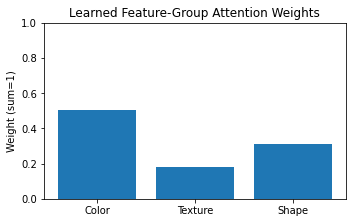

Saved: outputs_v2/figures/fig_attention_weights.png


In [17]:
plt.figure(figsize=(5, 3.2))
plt.bar(["Color", "Texture", "Shape"], alpha)
plt.ylim(0, 1)
plt.title("Learned Feature-Group Attention Weights")
plt.ylabel("Weight (sum=1)")
plt.tight_layout()

fig1_path = FIG_DIR / "fig_attention_weights.png"
plt.savefig(fig1_path, dpi=300)
plt.show()

print("Saved:", fig1_path)


In [25]:
def per_class_confidence(P_expert, y_true):
    n_classes = P_expert.shape[1]
    out = np.zeros((n_classes,), dtype=np.float64)
    for c in range(n_classes):
        idx = np.where(y_true == c)[0]
        out[c] = np.nan if len(idx) == 0 else np.mean(P_expert[idx, c])
    return out

conf_color = per_class_confidence(Pc_test, yt)
conf_text  = per_class_confidence(Pt_test, yt)
conf_shape = per_class_confidence(Ps_test, yt)

heat = np.vstack([conf_color, conf_text, conf_shape])     
heat_weighted = heat * alpha[:, None]                    


In [19]:
# 3) Texture features (GLCM + LBP) - EXACT ORIGINAL LOGIC
OUT_DIR = Path("outputs_v2")
IMG_SIZE = (256, 256)
EPS = 1e-8

DISTANCES = [1, 2]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"
LBP_BINS = LBP_POINTS + 2  # uniform

def glcm_features(gray_u8):
    levels = 16
    gray_q = (gray_u8 / (256 / levels)).astype(np.uint8)

    glcm = graycomatrix(
        gray_q,
        distances=DISTANCES,
        angles=ANGLES,
        levels=levels,
        symmetric=True,
        normed=True
    )
    feats = []
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop)
        feats.append(vals.mean())
        feats.append(vals.std())
    return np.array(feats, dtype=np.float32)

def lbp_features(gray_u8):
    gray = gray_u8.astype(np.float32) / 255.0
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_BINS + 1), density=False)
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + EPS)
    return hist

def extract_texture_features(df: pd.DataFrame):
    X = []
    for p in df["path"].tolist():
        img = cv2.imread(p)
        if img is None:
            raise RuntimeError(f"Could not read image: {p}")
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        g = glcm_features(gray)
        l = lbp_features(gray)
        X.append(np.concatenate([g, l]))

    X = np.vstack(X)

    glcm_names = []
    for prop in GLCM_PROPS:
        glcm_names += [f"glcm_{prop}_mean", f"glcm_{prop}_std"]
    lbp_names = [f"lbp_bin{i}" for i in range(LBP_BINS)]
    feat_names = glcm_names + lbp_names

    out = df[["path","label","label_id"]].copy()
    out[feat_names] = X
    return out

train_df = pd.read_csv(OUT_DIR / "train.csv")
val_df   = pd.read_csv(OUT_DIR / "val.csv")
test_df  = pd.read_csv(OUT_DIR / "test.csv")

print("Extracting texture features")
train_feat = extract_texture_features(train_df)
val_feat   = extract_texture_features(val_df)
test_feat  = extract_texture_features(test_df)

train_feat.to_csv(OUT_DIR / "texture_features_train.csv", index=False)
val_feat.to_csv(OUT_DIR / "texture_features_val.csv", index=False)
test_feat.to_csv(OUT_DIR / "texture_features_test.csv", index=False)

print("Saved texture features. Feature dim:", train_feat.shape[1] - 3)


Extracting texture features
Saved texture features. Feature dim: 22


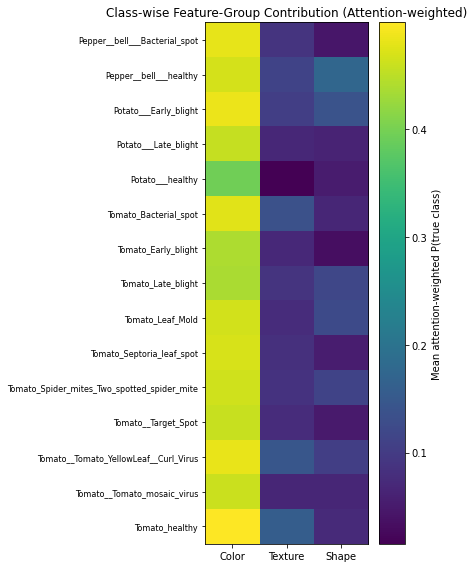

In [27]:
H = heat_weighted.T  

plt.figure(figsize=(6, 8))
plt.imshow(H, aspect="auto")
plt.colorbar(label="Mean attention-weighted P(true class)")

plt.xticks([0, 1, 2], ["Color", "Texture", "Shape"])

plt.yticks(
    np.arange(len(id2label)),
    [id2label[i] for i in range(len(id2label))],
    fontsize=8
)

plt.title("Class-wise Feature-Group Contribution (Attention-weighted)")
plt.tight_layout()
plt.show()




##  Key Takeaways

- Handcrafted features, when properly designed and combined, can achieve **very high accuracy** on controlled datasets.
- Color information is the dominant cue for leaf disease recognition, while texture and shape provide complementary signals.
- The proposed attention mechanism enhances **model transparency** by explicitly quantifying feature-group importance.
- A small drop in accuracy is acceptable in exchange for **interpretability**, especially in real-world agricultural systems.



##  Limitations & Notes

- The PlantVillage dataset contains images captured under controlled conditions.
- Performance may decrease under real-field scenarios with varying illumination and backgrounds.
- The attention mechanism operates at **feature-group level**, not pixel-level localization.



##  Future Extensions

- Lesion localization and severity estimation
- Field-condition robustness and domain adaptation
- Feature-level explainability (e.g., SHAP)
- Lightweight deployment on mobile or edge devices




> Rashin Gholijani Farahani,2025
> *Attention-Assisted Hybrid Feature Learning for Leaf Disease Pattern Recognition*


